<a href="https://colab.research.google.com/github/Jlia-miy/-/blob/main/9_%D0%A7%D0%B8%D1%81%D0%BB%D0%B5%D0%BD%D0%BD%D0%BE%D0%B5_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D1%83%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Немного теории

#### Введение

**Численные методы** — это приближённые способы решения математических задач, когда точное (аналитическое) решение найти сложно или невозможно.

Их используют, когда:

- нет явной формулы для ответа,

- уравнение слишком сложное для аналитического решения,

- нужно быстро получить ответ с заданной точностью.

Ключевая идея: вместо идеального точного решения мы получаем хорошее приближение, контролируя ошибку.

**Примеры, где применяются численные методы:**

- решение уравнений $f(x)=0$ (например, через метод Ньютона или бисекции),
- вычисление интегралов (метод трапеций, метод Симпсона),
- решение дифференциальных уравнений (методы Эйлера, Рунге-Кутты),
- линейная алгебра (нахождение собственных значений, решение систем уравнений),
- оптимизация (нахождение минимума функции).

Далее в этом ноутбуке рассматриваем только **численное решение уравнений** $f(x)=0.$

#### Основные методы численного решения уравнений

**Метод бисекции.** Деление интервала пополам

**Метод Ньютона.** Приближение по касательной

**Метод секущих.** Приближение без производной

**Метод Брента.** Комбинация нескольких методов для надёжности

У каждого из этих методов есть свои достоинства и недостатки. \
Подробное описание методов см. в литературе по численным методам.

**Почему важно уметь решать уравнения численно?**

В реальных задачах (физика, экономика, ML) уравнения редко решаются вручную → почти всегда применяются численные методы.

#### Терминология
**Корень уравнения** — значение $x$, при котором $f(x)=0$.

**Начальные условия** — отрезок или стартовая точка.

**Сходимость** — достижение корня с заданной точностью.

### Численное решение уравнений в Python

Численные методы решения уравнений в Python представлены в scipy.optimize.

**scipy.optimize.root_scalar** — универсальная и гибкая функция для решения уравнений.

Она объединяет в себе сразу несколько методов решения и позволяет производить вычисления более аккуратно и профессионально.

Документация: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html

**Почему root_scalar?**

- Универсальная функция для большинства методов.

- Позволяет выбрать метод: 'bisect', 'newton', 'secant', 'brentq', 'brenth', 'ridder'.

- Удобная проверка сходимости через .converged.

- Даёт подробную информацию: число итераций, сходимость и т.д.

**Пример.** Решить численно уравнение $x^3-x-2=0.$

In [ ]:
from scipy.optimize import root_scalar

def f(x):
    return x**3 - x - 2

# Поиск корня методом бисекции
sol = root_scalar(f, bracket=[1, 2], method='bisect')
sol

      converged: True
           flag: converged
 function_calls: 41
     iterations: 39
           root: 1.5213797068045096
         method: bisect

## Практическая часть

### Задание 1
Решить численно уравнение
$$x^3+4x^2-10=0$$
на отрезке [1, 2] методами 'bisect', 'newton', 'secant' через root_scalar.

а) Сравнить:
- число итераций,
- скорость сходимости,
- точность.

б) Построить график $f(x)=x^3+4x^2-10$ на отрезке [1, 2].

In [8]:
from scipy.optimize import root_scalar

def f(x):
    return x**3 + 4*x**2 - 10

# Поиск корня методом бисекции
sol = root_scalar(f, bracket=[1, 2], method='bisect')
print(sol.iterations)
sol


39


      converged: True
           flag: converged
 function_calls: 41
     iterations: 39
           root: 1.3652300134144753
         method: bisect

In [15]:
from scipy.optimize import root_scalar
from scipy import optimize
def f(x):
    return x**3 + 4*x**2 - 10

sol = optimize.root_scalar(f, x0=1.3, fprime=f, method='newton')
sol

      converged: False
           flag: convergence error
 function_calls: 100
     iterations: 50
           root: -48.7
         method: newton

In [16]:
from scipy.optimize import root_scalar
from scipy import optimize
def f(x):
    return x**3 + 4*x**2 - 10

sol = optimize.root_scalar(f, x0=1, x1=2, method='secant')
sol

      converged: True
           flag: converged
 function_calls: 7
     iterations: 6
           root: 1.3652300134142061
         method: secant

In [17]:
#Бибилиотеки
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

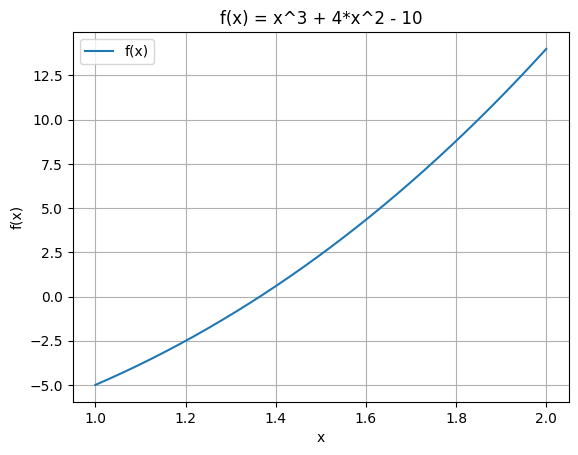

In [18]:
x = np.linspace(1, 2, 1000)
y = []
for value in x:
  y.append(f(value))

plt.plot(x, y, label="f(x)")
plt.title('f(x) = x^3 + 4*x^2 - 10')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

### Задание 2
Построить график функции
$$f(x)=e^{-x}-x$$
на [0, 1] и найти корень, используя метод Брента (method='brentq').

In [11]:
#Бибилиотеки
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

In [7]:
import math
from scipy.optimize import root_scalar
from scipy import optimize
def f(x):
    return math.e**(-x) - x
sol = optimize.root_scalar(f, bracket=[0, 1], method='brentq')
sol

      converged: True
           flag: converged
 function_calls: 8
     iterations: 7
           root: 0.5671432904097838
         method: brentq

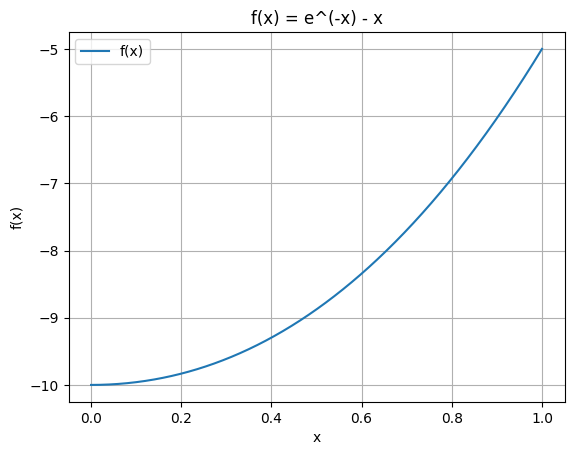

In [12]:
x = np.linspace(0, 1, 1000)
y = []
for value in x:
  y.append(f(value))

plt.plot(x, y, label="f(x)")
plt.title('f(x) = e^(-x) - x')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()